https://stackoverflow.com/questions/79890108/spherical-voronoi-heatmap-on-a-mollweide-projection

In [4]:
# Source - https://stackoverflow.com/q/79890108
# Posted by Pitchoune, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-17, License - CC BY-SA 4.0

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import SphericalVoronoi
def long_lat_from_xyz(x, y, z):
    lat = np.arcsin(z)
    long = np.arctan2(y, x)
    return long, lat

def sample_points(nb_points):
    # Sample points on the sphere and return their cartesian and long-lat coordinates
    long_lat = np.zeros(shape=(nb_points, 2))
    xyz = np.zeros(shape=(nb_points, 3))
    ratio = (1 + np.sqrt(5))*np.pi/2
    for i, x in enumerate(np.linspace(-1, 1, nb_points)):
        r = np.sqrt(1 - x**2)
        angle = i*ratio
        y = r*np.cos(angle)
        z = r*np.sin(angle)
        x, y, z = y, z, x # Cosmetic change to have the z-axis as the vertical one
        xyz[i, :] = [x, y, z]
        long_lat[i, :] = long_lat_from_xyz(x, y, z)
    return xyz, long_lat


In [5]:
# Source - https://stackoverflow.com/q/79890108
# Posted by Pitchoune, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-17, License - CC BY-SA 4.0

def are_points_on_opposite_sides(xyz1, xyz2):
    x1, y1, z1 = xyz1
    x2, y2, z2 = xyz2
    long1, _ =  long_lat_from_xyz(x1, y1, z1)
    long2, _ =  long_lat_from_xyz(x2, y2, z2)
    return (long1*long2 < 0) and (np.abs(long1) > np.pi/2) and (np.abs(long2) > np.pi/2)

def is_region_at_boundary(region):
    n = len(region)
    for i in range(n):
        v1 = sv.vertices[region][i]
        v2 = sv.vertices[region][(i + 1) % n]
        if are_points_on_opposite_sides(v1, v2):
            return True
    return False

def plot_region(region, ax):
    for i in range(len(region)):
        x_s, y_s, z_s = sv.vertices[region][i]
        x_e, y_e, z_e = sv.vertices[region][(i + 1) % len(region)]
        long_s, lat_s =  long_lat_from_xyz(x_s, y_s, z_s)
        long_e, lat_e =  long_lat_from_xyz(x_e, y_e, z_e)
        ax.plot([long_s, long_e], [lat_s, lat_e], color='k')


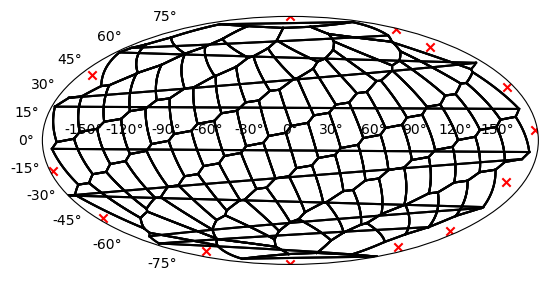

In [16]:
# Source - https://stackoverflow.com/q/79890108
# Posted by Pitchoune, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-17, License - CC BY-SA 4.0

nb_points = 100
xyz, long_lat = sample_points(nb_points)
sv = SphericalVoronoi(xyz, 1, np.array([0, 0, 0])) # xyz, radius, center
sv.sort_vertices_of_regions() 

fig = plt.figure()
ax = fig.add_subplot(111, projection='mollweide')

for n, region in enumerate(sv.regions):
    plot_region(region, ax)

    if not is_region_at_boundary(region):
        plot_region(region, ax)
    else:
        x, y, z = sv.points[n, :]
        long, lat = long_lat_from_xyz(x, y, z)
        ax.scatter(long, lat, marker='x', color='red')
plt.show()